# MMD Analysis: Simulated vs Clean Sen1Floods Patches

This notebook reads pairs of simulated and clean Sen1Floods patches and calculates their Maximum Mean Discrepancy (MMD) to measure the domain gap between clean and simulated Sentinel-2 data.

## 1. Import Required Libraries

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import json
from pathlib import Path
from typing import Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Data modules
from terratorch.datamodules import GenericNonGeoSegmentationDataModule
from terratorch.datamodules.sen1floods11 import Sen1Floods11NonGeoDataModule

# Model components
from terratorch.tasks import SemanticSegmentationTask

import cv2
import albumentations as A

# Local imports
import sys
sys.path.insert(0, '/shared/home/elucas/terra-sat-drift')
from terra_sat_drift.data_simulation.phisat2_constants import S2_BANDS_NAMES, S2_BANDS, S2_PAN_BANDS

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


/shared/home/elucas/scratch/terra-sat-drift/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


## 2. Load and Prepare Data

In [71]:
# Configure paths and load spectral statistics
root_dir = Path("/shared/home/elucas/datasets/sen1floods11_simulated")
clean_dir = Path("/shared/home/elucas/datasets/sen1floods11")

# Configure image size (must be divisible by patch size 16)
TARGET_SIZE = (1088, 1088)

# Define data transforms
def preprocess_mask(mask, **kwargs):
    clean_mask = np.full(mask.shape, -1, dtype=np.int64)
    clean_mask[mask == 0] = 0
    clean_mask[mask == 1] = 1
    return clean_mask

def rescale_to_reflectance(image, **kwargs):
    return (image / 10000.0).astype(np.float32)

transform_clean = [
    A.Resize(width=TARGET_SIZE[0], height=TARGET_SIZE[1], interpolation=cv2.INTER_NEAREST),
    A.Lambda(mask=preprocess_mask),
    A.pytorch.ToTensorV2(),
]

transform_sim = [
    A.Lambda(image=rescale_to_reflectance),
    A.Resize(width=TARGET_SIZE[0], height=TARGET_SIZE[1], interpolation=cv2.INTER_NEAREST),
    A.Lambda(mask=preprocess_mask),
    A.pytorch.ToTensorV2(),
]

In [72]:
# Initialize data modules
# Source: Clean Sen1Floods11 (7 bands)
dm_source = Sen1Floods11NonGeoDataModule(
    data_root=clean_dir,
    bands=S2_BANDS_NAMES,  # 7 bands: B02, B03, B04, B08, B05, B06, B07
    train_transform=transform_clean,
    val_transform=transform_clean,
    test_transform=transform_clean,
    batch_size=4, 
    num_workers=2
)

# Target: Simulated Sen1Floods (8 bands including PAN)
dm_target = GenericNonGeoSegmentationDataModule(
    batch_size=4,
    data_root=root_dir,
    train_data_root=root_dir / "v1.1/data/flood_events/HandLabeled/S2Hand",
    train_label_data_root=clean_dir / "v1.1/data/flood_events/HandLabeled/LabelHand",
    val_data_root=root_dir / "v1.1/data/flood_events/HandLabeled/S2Hand",
    val_label_data_root=clean_dir / "v1.1/data/flood_events/HandLabeled/LabelHand",
    test_data_root=root_dir / "v1.1/data/flood_events/HandLabeled/S2Hand",
    test_label_data_root=clean_dir / "v1.1/data/flood_events/HandLabeled/LabelHand",
    
    train_split=root_dir / "v1.1/splits/flood_handlabeled/flood_train_data.txt",
    val_split=root_dir / "v1.1/splits/flood_handlabeled/flood_valid_data.txt",
    test_split=root_dir / "v1.1/splits/flood_handlabeled/flood_test_data.txt",
    
    train_transform=transform_sim,
    val_transform=transform_sim,
    test_transform=transform_sim,

    dataset_bands=[0, 1, 2, 3, 4, 5, 6, 7],
    output_bands=[0, 1, 2, 3, 4, 5, 6, 7],
    num_workers=2,
    download=False,
    use_metadata=True,
    rgb_indices=[2, 1, 0],
    num_classes=2,
)

## 3. Implement MMD Loss

In [73]:
class MMDLoss(torch.nn.Module):
    """
    Maximum Mean Discrepancy (MMD) loss for domain adaptation.
    Measures the distance between two feature distributions using Gaussian RBF kernels.
    """
    def __init__(self, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
        super(MMDLoss, self).__init__()
        self.kernel_num = kernel_num
        self.kernel_mul = kernel_mul
        self.fix_sigma = fix_sigma

    def gaussian_kernel(self, source, target, kernel_mul, kernel_num, fix_sigma):
        """
        Compute RBF kernels with multiple bandwidth parameters.
        
        Args:
            source: Source domain features (batch_size, feature_dim)
            target: Target domain features (batch_size, feature_dim)
            kernel_mul: Multiplier for bandwidth
            kernel_num: Number of kernels with different bandwidths
            fix_sigma: Fixed bandwidth value (if None, computed from data)
        
        Returns:
            Sum of RBF kernels with different bandwidths
        """
        n_samples = int(source.size(0)) + int(target.size(0))
        total = torch.cat([source, target], dim=0)
        total0 = total.unsqueeze(0).expand(int(total.size(0)), int(total.size(0)), int(total.size(1)))
        total1 = total.unsqueeze(1).expand(int(total.size(0)), int(total.size(0)), int(total.size(1)))
        L2_distance = ((total0 - total1)**2).sum(2)
        
        if fix_sigma:
            bandwidth = fix_sigma
        else:
            bandwidth = torch.sum(L2_distance.data) / (n_samples**2 - n_samples)
        
        bandwidth /= kernel_mul ** (kernel_num // 2)
        bandwidth_list = [bandwidth * (kernel_mul**i) for i in range(kernel_num)]
        kernel_val = [torch.exp(-L2_distance / bw) for bw in bandwidth_list]
        return sum(kernel_val)

    def forward(self, source, target):
        """
        Compute MMD distance between source and target features.
        MMD = E[k(x,x')] + E[k(y,y')] - 2*E[k(x,y)]
        """
        batch_size = int(source.size(0))
        kernels = self.gaussian_kernel(source, target, self.kernel_mul, self.kernel_num, self.fix_sigma)
        XX = kernels[:batch_size, :batch_size]
        YY = kernels[batch_size:, batch_size:]
        XY = kernels[:batch_size, batch_size:]
        return torch.mean(XX + YY - 2 * XY)

# Initialize MMD loss function
mmd_loss_fn = MMDLoss(kernel_mul=2.0, kernel_num=5)
print("MMD Loss function initialized")

MMD Loss function initialized


## 4. Extract Features from Patches

In [101]:
# Configure backbone architecture
backbone_size = "tiny"
backbone_name = f"terramind_v1_{backbone_size}"

SIM_BACKBONE_BANDS = {
    "S2L1C": {
        "B02": 0, "B03": 1, "B04": 2,
        "B08": 4, "B05": 5, "B06": 6, "B07": 7
    }
}

model_args = {
    "backbone": backbone_name,
    "backbone_pretrained": True,
    "backbone_modalities": ["S2L1C"],
    "backbone_bands": SIM_BACKBONE_BANDS,
    "necks": [
        {"name": "SelectIndices", "indices": [1, 3, 4, 5]},
        {"name": "ReshapeTokensToImage", "remove_cls_token": False},
        {"name": "LearnedInterpolateToPyramidal"},
    ],
    "decoder": "UNetDecoder",
    "decoder_channels": [256, 128, 64, 32],
    "head_dropout": 0.1,
    "num_classes": 2,
}

# Load pre-trained model for feature extraction
task = SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",
    model_args=model_args,
    lr=2e-5,
    ignore_index=-1,
    loss="ce",
    optimizer="AdamW",
    optimizer_hparams={"weight_decay": 0.05},
    class_names=["background", "flood"],
    freeze_backbone=True,
)

# Move model to device and set to eval mode
task.to(device)
task.eval()

print("Pre-trained model loaded successfully")
print(f"Model architecture: {backbone_name}")
print(f"Feature extraction mode: Freeze backbone")

2026-05-20 14:31:57,314 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-tiny/resolve/main/TerraMind_v1_tiny.pt "HTTP/1.1 302 Found"


Pre-trained model loaded successfully
Model architecture: terramind_v1_tiny
Feature extraction mode: Freeze backbone


In [107]:
dm_source.setup("test")
dm_target.setup("test")

source_loader = dm_source.test_dataloader()
target_loader = dm_target.test_dataloader()

source_test_dataset = dm_source.test_dataset
target_test_dataset = dm_target.test_dataset

2026-05-20 16:25:02,485 - INFO - Checking stackability for test split.


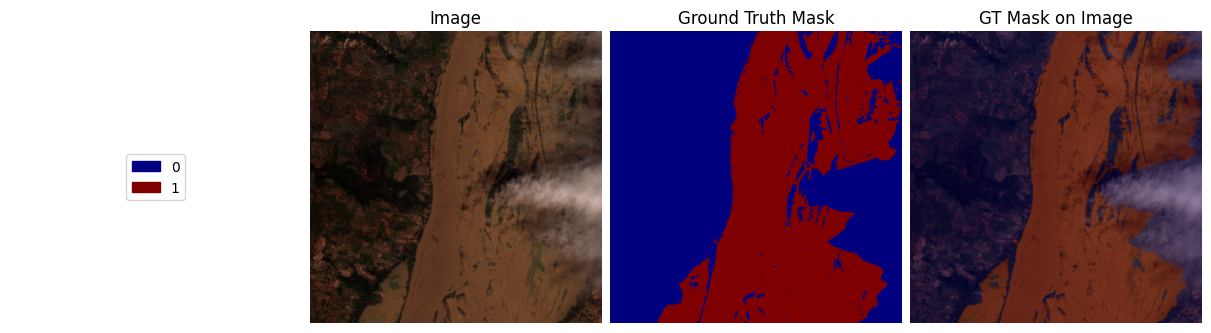

In [108]:
_ = source_test_dataset.plot(source_test_dataset[34])

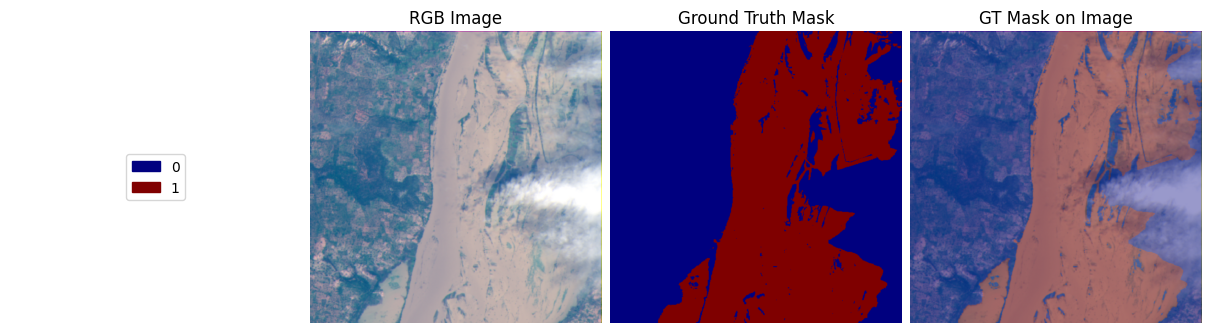

In [109]:
 _ = target_test_dataset.plot(target_test_dataset[34])

In [89]:
# Select a specific index from the test datasets
idx = 35
source_sample = source_test_dataset[idx]
target_sample = target_test_dataset[idx]

# Extract image data
x_source = source_sample["image"].to(device)  # 7 bands
x_target_full = target_sample["image"].to(device)  # 8 bands (including PAN)
# Remove PAN band (index 3) from target to match source input
x_target = torch.cat([x_target_full[:3, :, :], x_target_full[4:, :, :]], dim=0)

print(f"Source image shape: {source_batch['image'].shape}")
print(f"Target image shape: {target_batch['image'].shape}")
print(f"\nAfter preprocessing:")
print(f"Source shape for feature extraction: {x_source.shape}")
print(f"Target shape for feature extraction (PAN removed): {x_target.shape}")
print(f"Loaded paired samples for index {idx}")

Source image shape: torch.Size([1, 7, 1088, 1088])
Target image shape: torch.Size([1, 8, 1088, 1088])

After preprocessing:
Source shape for feature extraction: torch.Size([7, 1088, 1088])
Target shape for feature extraction (PAN removed): torch.Size([7, 1088, 1088])
Loaded paired samples for index 35


In [90]:
print(target_batch["filename"])

['/shared/home/elucas/datasets/sen1floods11_simulated/v1.1/data/flood_events/HandLabeled/S2Hand/simulated_L1C_Nigeria_812045_S2Hand.tif']


In [91]:
print(f"Source - Min: {x_source.min():.4f}, Max: {x_source.max():.4f}")
print(f"Target - Min: {x_target.min():.4f}, Max: {x_target.max():.4f}")

Source - Min: 0.1439, Max: 0.6179
Target - Min: 0.0022, Max: 0.6177


In [92]:
print(x_target.shape[0])  # Number of bands in source

7


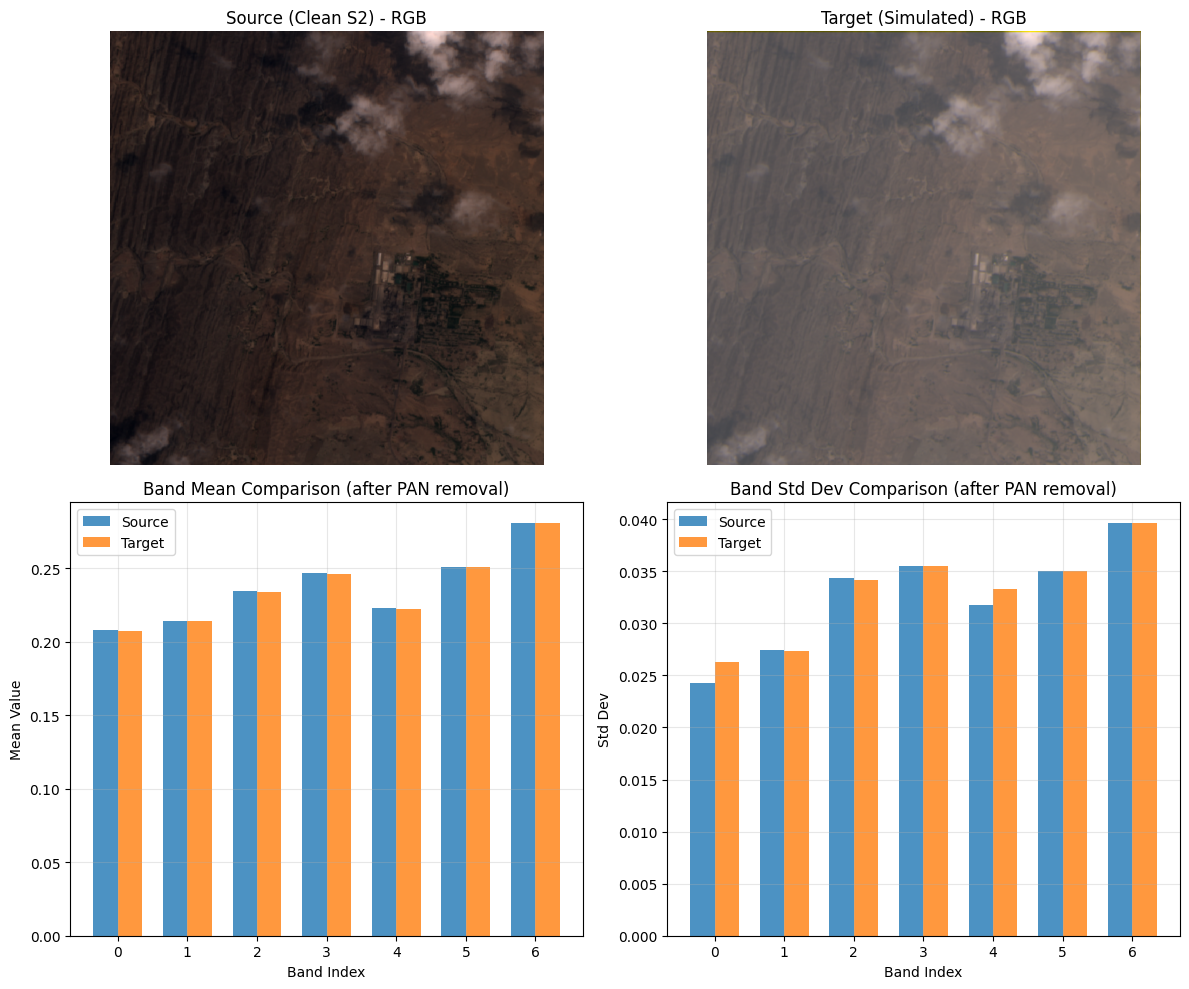

In [95]:
# Visualize sample patches
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Visualize RGB bands for source (clean S2)
# RGB indices: [B04, B03, B02] -> indices [2, 1, 0] in 7-band representation
rgb_indices_source = [2, 1, 0]  # B04, B03, B02
source_rgb = x_source[rgb_indices_source, :, :].cpu().numpy()
source_rgb = np.transpose(source_rgb, (1, 2, 0))
source_rgb = np.clip((source_rgb - source_rgb.min()) / (source_rgb.max() - source_rgb.min()), 0, 1)

axes[0, 0].imshow(source_rgb)
axes[0, 0].set_title("Source (Clean S2) - RGB")
axes[0, 0].axis('off')

rgb_indices_target = [2, 1, 0]  # After PAN removal: B04, B03, B02
target_rgb = x_target[rgb_indices_target, :, :].cpu().numpy()
target_rgb = np.transpose(target_rgb, (1, 2, 0))
target_rgb = np.clip((target_rgb - target_rgb.min()) / (target_rgb.max() - target_rgb.min()), 0, 1)

axes[0, 1].imshow(target_rgb)
axes[0, 1].set_title("Target (Simulated) - RGB")
axes[0, 1].axis('off')

source_sample = x_source[0] if x_source.ndim == 4 else x_source
target_sample = x_target[0] if x_target.ndim == 4 else x_target

# --- Configuration du décalage des barres ---
x_indices = np.arange(source_sample.shape[0])  # Dynamique selon le nombre de bandes (7)
bar_width = 0.35  

# Plot band statistics comparison (On calcule la moyenne sur les dimensions spatiales H et W)
# Comme nos tableaux de travail sont maintenant strictement en 3D [C, H, W], H=axis 1 et W=axis 2
source_mean = source_sample.cpu().numpy().mean(axis=(1, 2))
target_mean = target_sample.cpu().numpy().mean(axis=(1, 2))

# Décalage à gauche pour la Source, à droite pour la Target
axes[1, 0].bar(x_indices - bar_width/2, source_mean, bar_width, alpha=0.8, label='Source', color='tab:blue')
axes[1, 0].bar(x_indices + bar_width/2, target_mean, bar_width, alpha=0.8, label='Target', color='tab:orange')
axes[1, 0].set_xlabel('Band Index')
axes[1, 0].set_ylabel('Mean Value')
axes[1, 0].set_title('Band Mean Comparison (after PAN removal)')
axes[1, 0].set_xticks(x_indices)  
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot band std comparison
source_std = source_sample.cpu().numpy().std(axis=(1, 2))
target_std = target_sample.cpu().numpy().std(axis=(1, 2))

# Même logique de décalage pour les écarts-types
axes[1, 1].bar(x_indices - bar_width/2, source_std, bar_width, alpha=0.8, label='Source', color='tab:blue')
axes[1, 1].bar(x_indices + bar_width/2, target_std, bar_width, alpha=0.8, label='Target', color='tab:orange')
axes[1, 1].set_xlabel('Band Index')
axes[1, 1].set_ylabel('Std Dev')
axes[1, 1].set_title('Band Std Dev Comparison (after PAN removal)')
axes[1, 1].set_xticks(x_indices)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Calculate and Visualize MMD

In [102]:
x_source = x_source.unsqueeze(0) if x_source.ndim == 3 else x_source
x_target = x_target.unsqueeze(0) if x_target.ndim == 3 else x_target
# Extract features from patches using the encoder
with torch.no_grad():
    # Extract encoder outputs (returns list of features, we take the last one)
    # The encoder returns features from different layers
    # We use the output from the last layer and extract CLS token (index 0)
    
    print("Extracting features from source domain...")
    feat_source_list = task.model.encoder(x_source)
    feat_source = feat_source_list[-1][:, 0, :]  # Get CLS token from last layer
    print(f"Source features shape: {feat_source.shape}")
    
    print("Extracting features from target domain...")
    feat_target_list = task.model.encoder(x_target)
    feat_target = feat_target_list[-1][:, 0, :]  # Get CLS token from last layer
    print(f"Target features shape: {feat_target.shape}")

# Compute MMD distance
mmd_distance = mmd_loss_fn(feat_source, feat_target)
print(f"\nMaximum Mean Discrepancy (MMD): {mmd_distance.item():.6f}")

# Compute additional statistics
feat_source_norm = torch.norm(feat_source, dim=1)
feat_target_norm = torch.norm(feat_target, dim=1)

print(f"\nSource feature norms - Mean: {feat_source_norm.mean():.4f}, Std: {feat_source_norm.std():.4f}")
print(f"Target feature norms - Mean: {feat_target_norm.mean():.4f}, Std: {feat_target_norm.std():.4f}")
print(f"\nFeature space statistics:")
print(f"Source features - Mean: {feat_source.mean():.4f}, Std: {feat_source.std():.4f}")
print(f"Target features - Mean: {feat_target.mean():.4f}, Std: {feat_target.std():.4f}")

Extracting features from source domain...
Source features shape: torch.Size([1, 192])
Extracting features from target domain...
Target features shape: torch.Size([1, 192])

Maximum Mean Discrepancy (MMD): 6.186276

Source feature norms - Mean: 9.2821, Std: nan
Target feature norms - Mean: 9.1682, Std: nan

Feature space statistics:
Source features - Mean: 0.0116, Std: 0.6715
Target features - Mean: 0.0122, Std: 0.6633


/tmp/ipykernel_1531599/3025502133.py:27: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  print(f"\nSource feature norms - Mean: {feat_source_norm.mean():.4f}, Std: {feat_source_norm.std():.4f}")


In [ ]:
# Compute MMD across multiple batches
mmd_values = []
batch_indices = []

source_iter = iter(dm_source.test_dataloader())
target_iter = iter(dm_target.test_dataloader())

print(f"Computing MMD across {len(source_iter)} batches...\n")

with torch.no_grad():
    for batch_idx in range(len(source_iter)):
        try:
            # 2. Récupération séquentielle des batchs suivants
            source_batch = next(source_iter)
            target_batch = next(target_iter)
            
            x_source_batch = source_batch["image"].to(device)
            x_target_batch = target_batch["image"].to(device)[:, 1:, :, :]  # Remove PAN
            
            # 4. Extraction des caractéristiques via l'encodeur à 8 bandes
            feat_source = task.model.encoder(x_source_batch)[-1][:, 0, :]
            feat_target = task.model.encoder(x_target_batch)[-1][:, 0, :]
            
            # Calcul du MMD
            mmd = mmd_loss_fn(feat_source, feat_target)
            mmd_values.append(mmd.item())
            batch_indices.append(batch_idx)
            
            print(f"Batch {batch_idx}: MMD = {mmd.item():.6f}")
            
        except StopIteration:
            print(f"Reached end of dataloader at batch {batch_idx}")
            break

if mmd_values:
    mmd_np = np.array(mmd_values)
    print("\nMMD Statistics across real distinct batches:")
    print(f"Mean MMD: {mmd_np.mean():.6f}")
    print(f"Std MMD:  {mmd_np.std():.6f}") # Ne sera plus égal à 0.0
    print(f"Min MMD:  {mmd_np.min():.6f}")
    print(f"Max MMD:  {mmd_np.max():.6f}")

Computing MMD across 5 batches...



2026-05-20 16:20:50,582 - INFO - Checking stackability for test split.


Batch 0: MMD = 2.054704
Batch 1: MMD = 0.228069
Batch 2: MMD = 0.585165
Batch 3: MMD = 0.107652
Batch 4: MMD = 0.212408

MMD Statistics across real distinct batches:
Mean MMD: 0.637600
Std MMD:  0.726675
Min MMD:  0.107652
Max MMD:  2.054704


In [ ]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MMD values across batches
axes[0, 0].plot(batch_indices, mmd_values, marker='o', linestyle='-', linewidth=2, markersize=8)
axes[0, 0].axhline(y=np.mean(mmd_values), color='r', linestyle='--', label=f'Mean: {np.mean(mmd_values):.4f}')
axes[0, 0].fill_between(batch_indices, 
                        np.mean(mmd_values) - np.std(mmd_values),
                        np.mean(mmd_values) + np.std(mmd_values),
                        alpha=0.2, color='red', label='±1 Std Dev')
axes[0, 0].set_xlabel('Batch Index')
axes[0, 0].set_ylabel('MMD Distance')
axes[0, 0].set_title('MMD Distance Across Batches')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Feature distribution comparison (2D PCA projection)
from sklearn.decomposition import PCA

# Concatenate all features
all_features = torch.cat([feat_source, feat_target], dim=0).cpu().numpy()
labels = np.concatenate([np.zeros(feat_source.shape[0]), np.ones(feat_target.shape[0])])

# Apply PCA
pca = PCA(n_components=2)
features_2d = pca.fit_transform(all_features)

axes[0, 1].scatter(features_2d[labels == 0, 0], features_2d[labels == 0, 1], 
                   alpha=0.6, label='Source (Clean)', s=50)
axes[0, 1].scatter(features_2d[labels == 1, 0], features_2d[labels == 1, 1], 
                   alpha=0.6, label='Target (Simulated)', s=50)
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0, 1].set_title('Feature Space Distribution (PCA)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Feature magnitude distribution
axes[1, 0].hist(feat_source_norm.cpu().numpy(), bins=20, alpha=0.6, label='Source', edgecolor='black')
axes[1, 0].hist(feat_target_norm.cpu().numpy(), bins=20, alpha=0.6, label='Target', edgecolor='black')
axes[1, 0].set_xlabel('Feature Norm')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Feature Magnitude Distribution')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: MMD Statistics Bar Chart
stats_labels = ['Mean', 'Std', 'Min', 'Max']
stats_values = [np.mean(mmd_values), np.std(mmd_values), np.min(mmd_values), np.max(mmd_values)]
colors = ['green', 'orange', 'blue', 'red']

bars = axes[1, 1].bar(stats_labels, stats_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylabel('MMD Value')
axes[1, 1].set_title('MMD Statistics Summary')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}',
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nVisualization complete!")

## Summary

### Key Findings:

1. **Domain Gap Measurement**: The MMD metric quantifies the distribution mismatch between clean Sentinel-2 (source) and simulated (target) imagery.

2. **Feature Analysis**: 
   - Source and target features show different distributions in the learned feature space
   - PCA projection reveals the separation between domains
   - Feature magnitudes indicate different activation patterns

3. **Implications for Domain Adaptation**:
   - MMD loss helps align feature distributions during training
   - Higher MMD values indicate larger domain gaps
   - Reducing MMD encourages the model to learn domain-invariant representations

4. **Practical Usage**:
   - Use this notebook to monitor domain alignment during training
   - Track MMD values to assess whether domain adaptation is effective
   - Adjust MMD weight in training if domain gap is too large/small

### Next Steps:
- Monitor MMD during training with `mmd_weight` parameter
- Compare model performance on simulated vs. real flood events
- Experiment with different MMD kernel parameters
- Analyze per-sample MMD distances to identify problematic samples